In [17]:
import pandas as pd
from pathlib import Path
from IPython.display import display
from plotter import plot_series

RUNS_DIR = Path("../runs")
STRATEGIES = ["hold", "buybelow"]


def latest_steps(strategy: str) -> Path:
    matches = sorted(RUNS_DIR.glob(f"{strategy}_*"), reverse=True)
    if not matches:
        raise FileNotFoundError(f"No runs found for {strategy!r} in {RUNS_DIR}")
    return matches[0] / "steps.jsonl"


In [18]:
runs = {
    name: pd.read_json(latest_steps(name), lines=True)
    for name in STRATEGIES
}

for name, steps in runs.items():
    print(name, "->", latest_steps(name).parent.name)
    display(steps)


hold -> hold_26-07-17_16-49


,step,time,price,decision,balances,positions,equity
0,0,2021-01-01 00:00:00,29331.69,"[{'ticker': 'BTC', 'side': 'BUY', 'quantity': ...",{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",10000.000000
1,1,2021-01-02 00:00:00,32178.33,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",10970.499825
2,2,2021-01-03 00:00:00,33000.05,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",11250.647337
3,3,2021-01-04 00:00:00,31988.71,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",10905.853021
4,4,2021-01-05 00:00:00,33949.53,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",11574.351836
...,...,...,...,...,...,...,...
2018,2018,2026-07-12 00:00:00,63780.00,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",21744.399999
2019,2019,2026-07-13 00:00:00,62334.52,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",21251.595118
2020,2020,2026-07-14 00:00:00,65043.98,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",22175.326413
2021,2021,2026-07-15 00:00:00,64756.28,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.340928190636...",22077.241373


buybelow -> buybelow_26-07-17_16-49


,step,time,price,decision,balances,positions,equity
0,0,2021-01-01 00:00:00,29331.69,[],{'USD': '10000'},[],10000.000000
1,1,2021-01-02 00:00:00,32178.33,[],{'USD': '10000'},[],10000.000000
2,2,2021-01-03 00:00:00,33000.05,[],{'USD': '10000'},[],10000.000000
3,3,2021-01-04 00:00:00,31988.71,[],{'USD': '10000'},[],10000.000000
4,4,2021-01-05 00:00:00,33949.53,[],{'USD': '10000'},[],10000.000000
...,...,...,...,...,...,...,...
2018,2018,2026-07-12 00:00:00,63780.00,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",33620.107544
2019,2019,2026-07-13 00:00:00,62334.52,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",32858.157199
2020,2020,2026-07-14 00:00:00,65043.98,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",34286.384489
2021,2021,2026-07-15 00:00:00,64756.28,[],{'USD': '1E-24'},"[{'ticker': 'BTC', 'quantity': '0.527126176611...",34134.730288


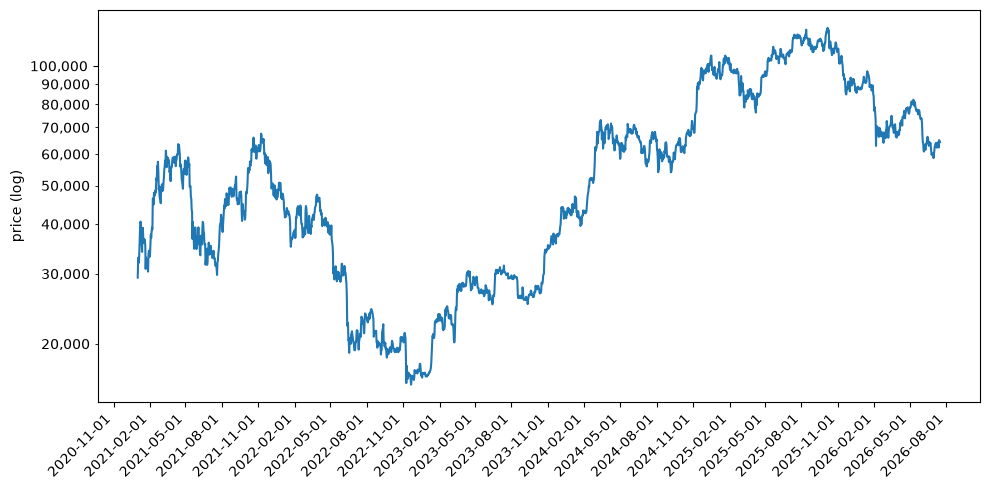

In [11]:
plot_series(next(iter(runs.values())), "price")


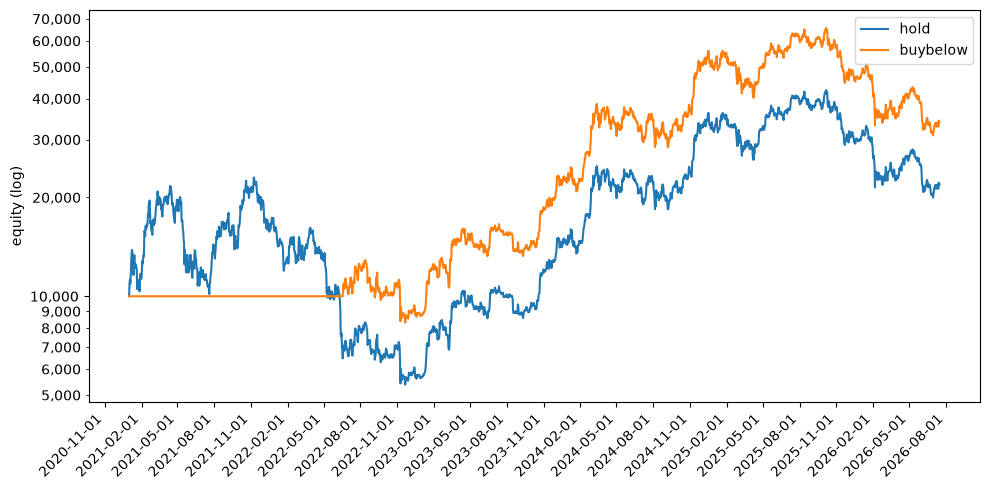

In [12]:
plot_series(runs, "equity")
